# Dataset Customer
- Como aclaracion si se desea ejecutar o hacer la prueba, se debera tener el dataset en tu propio drive en la seccion que dice mi unidad, para no tener conflictos de rutas, luego se le pedira acceso al drive debe acceptar

---

## Estructura del notebook

0. **Configuración inicial** — importaciones, rutas y parámetros (se definen una sola vez).
1. **Pre-procesamiento de datos** — exploración, limpieza, datos faltantes e imputación.
2. **Determinación de datos de entrenamiento del modelo** — features/target, división train/test y preprocesamiento para ML.
3. **Validación con al menos 5 métricas** — un subapartado por modelo (SVM, Regresión Logística, Árbol de Decisión, Red Neuronal), comparación y **ajuste de los modelos y prevención de overfitting**.
4. **Predicciones con datos ingresados por el usuario** e interpretación.


## Configuración inicial

Todas las **importaciones**, **rutas** y **parámetros reutilizados** se definen aquí, una sola vez

- En Google Colab se monta Drive y el dataset (`Customer.csv`) debe estar en *Mi unidad*.
- Fuera de Colab se usa la carpeta actual.
- `RANDOM_STATE`, `TEST_SIZE`, `CV_FOLDS` y `GAP_MAX_CV` controlan la reproducibilidad, la división train/test, la validación cruzada y el criterio anti-overfitting (secciones 2 y 3).

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


In [ ]:
# 1. Configuración de rutas locales (Sube un nivel desde la carpeta del notebook)
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data" / "customers"

# 2. Definición de archivos con la nueva ruta
PATH_RAW = DATA_DIR / "Customer.csv"
PATH_CLEAN = DATA_DIR / "Customer_clean.csv"
PATH_SEGMENT = DATA_DIR / "Customer_segment_preprocessed.csv"

# 3. Parámetros del proyecto
RANDOM_STATE = 42          
TEST_SIZE = 0.20           
CV_FOLDS = 5               
GAP_MAX_CV = 0.10          
N_JOBS = -1                
EXPORTAR_PREPROCESADO = True   
MODO_INTERACTIVO = True        

TARGET = "segment"
FEATURES_NUM = ["age"]
FEATURES_CAT = ["city", "state", "postal_code", "region"]

# 4. Configuraciones globales
os.environ["PYTHONWARNINGS"] = "ignore"   
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

print("Rutas configuradas con éxito.")
print("Archivo origen:", PATH_RAW)

Rutas configuradas con éxito.
Archivo origen: /home/jessihdd/Universidad/Data-Science/Proyecto/machine-learning-primer-parcial/data/Customer.csv


# 1. Pre-procesamiento de datos

Esta sección reúne todo lo que se hace sobre los datos **antes** de pensar en modelos. Se organiza en:

1. **Exploración** — revisar tipos, nulos, categorías y valores malformados.
2. **Limpieza** — normalizar nombres, texto, tipos y duplicados.
3. **Datos faltantes e imputación** — qué se encontró y qué decisión se tomó.
4. **Resumen de técnicas** — tabla con cada transformación, dónde se aplica y por qué.

Todo el preprocesamiento se hace **directamente con código en este notebook** (`polars`, `pandas`, `scikit-learn`). No se usaron herramientas externas (Excel, OpenRefine, editores de CSV, etc.) para limpiar, transformar o imputar datos.

## 1.1 Exploración

Primero vamos a ver que tiene el dataset:



In [13]:
df = pl.read_csv(PATH_RAW)
df

Customer ID,Customer Name,Segment,Age,Country,City,State,Postal Code,Region
str,str,str,i64,str,str,str,i64,str
"""CG-12520""","""Claire Gute""","""Consumer""",67,"""United States""","""Henderson""","""Kentucky""",42420,"""South"""
"""DV-13045""","""Darrin Van Huff""","""Corporate""",31,"""United States""","""Los Angeles""","""California""",90036,"""West"""
"""SO-20335""","""Sean O'Donnell""","""Consumer""",65,"""United States""","""Fort Lauderdale""","""Florida""",33311,"""South"""
"""BH-11710""","""Brosina Hoffman""","""Consumer""",20,"""United States""","""Los Angeles""","""California""",90032,"""West"""
"""AA-10480""","""Andrew Allen""","""Consumer""",50,"""United States""","""Concord""","""North Carolina""",28027,"""South"""
…,…,…,…,…,…,…,…,…
"""CJ-11875""","""Carl Jackson""","""Corporate""",64,"""United States""","""Philadelphia""","""Pennsylvania""",19140,"""East"""
"""RS-19870""","""Roy Skaria""","""Home Office""",39,"""United States""","""Burlington""","""Iowa""",52601,"""Central"""
"""SC-20845""","""Sung Chung""","""Consumer""",69,"""United States""","""Arlington Heights""","""Illinois""",60004,"""Central"""


## Descripcion del dataset
Vemos que tiene un shape de 793 rows X 9 columns ( 9 features ), con el primer vistaso, vemos atributo por atributo:
- CustomerID: Codigos, tiene dos letras seguido de numeros. Estas dos primeras letras pareciera ser las iniales de CustomerName. Pareciera ser una variable dependiente
- CustomerName: Nombre de los clientes pareciera ser que solo es un nombre y un apellido
- Segment: Pareciera ser una clasificacion del tipo de cliente
- Age: Edad del cliente
- Country: Pais de los clientes
- City: ciudad de los clientes
- State: Estado (de eeuu pareciera) de los clientes
- PostalCode: codigo postal del cliente
- Region: clasificacion de donde queda.

Ahora vamos a ver si existe campos nullos, blancos o malformados.

In [14]:
conteo_nulos = df.null_count()
conteo_nulos

Customer ID,Customer Name,Segment,Age,Country,City,State,Postal Code,Region
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


no tenemos ningun nulo en el dataset. entonces ahora veremos, que columnas son verdaderamente categoricas, estas son:
- Segment
- Country
- City
- State
- PostalCode
- Region

In [15]:
def sacar_lista_unicos_columnas(df, list_column_names) -> dict[str, list[str]]:
    resp = {}
    for column in list_column_names:
        resp[column] = df[column].unique().to_list()
    return resp

In [16]:
sacar_lista_unicos_columnas(
    df, ["Segment", "Country", "City", "State", "Postal Code", "Region"]
)

{'Segment': ['Consumer', 'Corporate', 'Home Office'],
 'Country': ['United States'],
 'City': ['Baltimore',
  'Mishawaka',
  'Littleton',
  'San Diego',
  'Mobile',
  'Colorado Springs',
  'Salem',
  'West Jordan',
  'Macon',
  'Orland Park',
  'Arlington Heights',
  'Quincy',
  'Ontario',
  'Greenville',
  'Lorain',
  'Tallahassee',
  'New York City',
  'Medina',
  'Memphis',
  'Clarksville',
  'Greensboro',
  'Roseville',
  'Chester',
  'Mesa',
  'Trenton',
  'Skokie',
  'Perth Amboy',
  'Oklahoma City',
  'Irving',
  'Pico Rivera',
  'Grand Prairie',
  'Cranston',
  'Costa Mesa',
  'Bloomington',
  'Westfield',
  'Saginaw',
  'Warner Robins',
  'Arvada',
  'Hackensack',
  'Franklin',
  'Mission Viejo',
  'Coppell',
  'New Albany',
  'Gulfport',
  'San Antonio',
  'Fort Collins',
  'Bowling Green',
  'Linden',
  'Monroe',
  'Rochester Hills',
  'Houston',
  'Harlingen',
  'Florence',
  'Laguna Niguel',
  'Columbia',
  'Saint Petersburg',
  'Allen',
  'Cincinnati',
  'Highland Park',


Vemos, varias cosas, no existe valores blancos, detallamos informacion encontrada:
- Segment: solo tiene 3 'Corporate', 'Home Office', 'Consumer'
- Country: Es solo de EEUU
- Region: Solo tiene 4, ['South', 'Central', 'East', 'West'].
Por el momento las otras columnas tenemos que obtener mas datos, una aproximacion para ver datos malformado seria contar los estados si superan mas de 50, ciudades que tambien superan, como los codigos postales que tiene eeuu son 41500, supera por mucho la cantidad de rows, Pero vamos a ver cuantos existen.

In [17]:
def sacar_conteo_unicos_columnas(df, list_column_names) -> dict[str, int]:
    resp = {}
    for column in list_column_names:
        resp[column] = len(df[column].unique().to_list())
    return resp

In [18]:
sacar_conteo_unicos_columnas(df, ["City", "State", "Postal Code"])
sacar_conteo_unicos_columnas(df, ["Customer ID", "Customer Name"])

{'Customer ID': 793, 'Customer Name': 793}

Tenemos 41 estados, 252 ciudades y 314 codigos postales, entonces son todos validos estos.

Verificaremos datos repetidos con el CustomerId.

In [19]:
def cantidad_palabras(nombre: str):
    nombre = nombre.strip()
    conteo = len(nombre.split())
    return conteo


custumer_conteo = df["Customer Name"].map_elements(cantidad_palabras).unique().to_list()

In [20]:
custumer_conteo

[1, 2, 3]

Los resultados muestran que existe 3 palabras en las columnas entonces puede que exista un solo nombre, o hasta 3 Palabras por nombre. Igualmente vamos a verificar las letras de ID.

In [21]:
def cantidad_letras(nombre: str):
    nombre = nombre.strip()
    conteo = len(nombre.split("-")[0])
    return conteo


custumer_id_conteo = df["Customer ID"].map_elements(cantidad_letras).unique().to_list()
customers_filtrados = df.filter(
    df["Customer Name"].map_elements(cantidad_palabras).is_in([1, 3])
)

In [22]:
customers_filtrados

Customer ID,Customer Name,Segment,Age,Country,City,State,Postal Code,Region
str,str,str,i64,str,str,str,i64,str
"""DV-13045""","""Darrin Van Huff""","""Corporate""",31,"""United States""","""Los Angeles""","""California""",90036,"""West"""
"""SA-20830""","""Sue Ann Reed""","""Consumer""",34,"""United States""","""Chicago""","""Illinois""",60610,"""Central"""
"""SC-20050""","""Sample Company A""","""Home Office""",38,"""United States""","""Norwich""","""Connecticut""",6360,"""East"""
"""PV-18985""","""Paul Van Hugh""","""Home Office""",64,"""United States""","""San Francisco""","""California""",94122,"""West"""
"""Co-12640""","""Corey-Lock""","""Consumer""",55,"""United States""","""Philadelphia""","""Pennsylvania""",19143,"""East"""
"""MV-17485""","""Mark Van Huff""","""Consumer""",54,"""United States""","""Arlington""","""Virginia""",22204,"""South"""


In [23]:
custumer_id_conteo

[2]

Siempre son dos letras en el Customer ID, vamos a buscar las rows donde aparezcan 1, y 3 palabras para ver relacion.

Son solo 6 datos, quizas no son tan importantes, aun asi. En caso de 3 palabras se toma las primeras 2 iniciales para Customer ID, y en el cas de una palabra, es el unico caso que pone el codigo como Mayuscula la primera letra y 2da letra como minuscula el dato es: "Co-12640"	"Corey-Lock"

Verificamos como ultimo la edad, si existe valores negativos.

In [24]:
conteo_negativos = df.filter(pl.col("Age") < 0).height
conteo_negativos

0

No existe edades negativas por lo tanto no se encontro datos malformados en el dataset. como polars intuye los tipos de las columnas automaticamente, no se necesita verficar si esta mezclado ya que hubiera aparecido como dato OBJECT, en su lugar si reconocio String, i64.

## 1.2 Limpieza

In [25]:
def cargar_datos(ruta: Path = PATH_RAW) -> pl.DataFrame:
    """Carga el dataset Customer en formato CSV."""
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo en: {ruta}")
    return pl.read_csv(ruta)

In [26]:
def estandarizar_columnas(df: pl.DataFrame) -> pl.DataFrame:
    """Normaliza los nombres de columnas a snake_case sin espacios."""
    mapeo = {col: col.strip().lower().replace(" ", "_") for col in df.columns}
    return df.rename(mapeo)

In [27]:
def limpiar_datos(df: pl.DataFrame) -> pl.DataFrame:
    """
    Ejecuta el pipeline de limpieza:
    - Normalización de encabezados.
    - Limpieza de espacios en strings (strip_chars).
    - Unificación a mayúsculas de IDs (corrige 'Co-12640' -> 'CO-12640').
    - Casteo de postal_code a String.
    - Descarte de duplicados por customer_id.
    - Eliminación de columna country (varianza cero).
    """
    # 1. Normalizar columnas
    df_clean = estandarizar_columnas(df)

    # 2. Corrección de tipos y limpieza de texto
    df_clean = df_clean.with_columns(
        [
            pl.col("customer_id").str.to_uppercase().str.strip_chars(),
            pl.col("customer_name").str.strip_chars(),
            pl.col("segment").str.strip_chars(),
            pl.col("city").str.strip_chars(),
            pl.col("state").str.strip_chars(),
            pl.col("region").str.strip_chars(),
            pl.col("postal_code").cast(pl.String),
        ]
    )

    # 3. Eliminar duplicados si existieran
    df_clean = df_clean.unique(subset=["customer_id"], maintain_order=True)

    # 4. Descartar columna 'country' (solo contiene 'United States')
    if "country" in df_clean.columns:
        df_clean = df_clean.drop("country")

    return df_clean

In [28]:
def guardar_datos(df: pl.DataFrame, ruta_salida: Path = PATH_CLEAN) -> None:
    df.write_csv(ruta_salida)
    print(f"[OK] Archivo limpio generado en: {ruta_salida}")

In [29]:
print("Iniciando pipeline de limpieza...")
df_raw = cargar_datos()
print(f"Filas originales: {df_raw.height}")

df_limpio = limpiar_datos(df_raw)
print(f"Filas limpias: {df_limpio.height}")
print(f"Columnas finales ({len(df_limpio.columns)}): {df_limpio.columns}")

guardar_datos(df_limpio)

Iniciando pipeline de limpieza...
Filas originales: 793
Filas limpias: 793
Columnas finales (8): ['customer_id', 'customer_name', 'segment', 'age', 'city', 'state', 'postal_code', 'region']
[OK] Archivo limpio generado en: /home/jessihdd/Universidad/Data-Science/Proyecto/machine-learning-primer-parcial/data/Customer_clean.csv


# 2. Determinación de datos de entrenamiento del modelo

Se aborda un problema de **clasificación multiclase supervisada**: predecir el tipo de cliente (`segment`) a partir de variables demográficas y geográficas, usando el dataset limpio (`Customer_clean.csv`) generado en la sección 1.

## 2.1 Features y target

In [30]:
df_ml = pd.read_csv(PATH_CLEAN, dtype={"postal_code": str})

X = df_ml[FEATURES_NUM + FEATURES_CAT]
y = df_ml[TARGET]
CLASES = sorted(y.unique())

print(f"Features (X): {list(X.columns)}   ->  forma {X.shape}")
print(f"Target   (y): '{TARGET}'  ->  clases {CLASES}")
print("\nColumnas descartadas:", [c for c in df_ml.columns if c not in X.columns and c != TARGET])
display(y.value_counts().to_frame("registros").assign(porcentaje=lambda d: (100 * d["registros"] / len(y)).round(1)))

Features (X): ['age', 'city', 'state', 'postal_code', 'region']   ->  forma (793, 5)
Target   (y): 'segment'  ->  clases ['Consumer', 'Corporate', 'Home Office']

Columnas descartadas: ['customer_id', 'customer_name']


,registros,porcentaje
segment,,
Consumer,409,51.6
Corporate,236,29.8
Home Office,148,18.7


### Justificación de la selección

**Target (`y = segment`).** Es la variable de negocio que se quiere anticipar: el tipo de cliente (`Consumer`, `Corporate`, `Home Office`). Saber el segmento de un cliente nuevo permite orientar ofertas, precios y comunicación. Es categórica con 3 clases y desbalanceada (≈ 52 % / 30 % / 19 %), por lo que se trata como **clasificación multiclase** y se cuida el desbalance al dividir y al evaluar.

**Features (`X`).** Son toda la información *descriptiva y disponible al registrar un cliente* que contiene el dataset:

| Feature | Tipo | Por qué es relevante |
|---|---|---|
| `age` | numérica | El tipo de comprador (particular, profesional independiente, empresa) puede correlacionar con la etapa de vida. |
| `city`, `state`, `postal_code` | categóricas | El entorno geográfico (urbano/empresarial vs. residencial) puede influir en el tipo de cliente. |
| `region` | categórica | Agrupación macro de la ubicación; se reutiliza como predictor (en otro problema del proyecto es el propio target). |

**Columnas descartadas.**
- `customer_id` y `customer_name`: identificadores únicos por cliente. No contienen señal que generalice a clientes nuevos y sólo facilitarían la memorización (además el ID deriva del nombre).
- `country`: constante (ya eliminada en la limpieza).

**Hipótesis y advertencia.** No existe una relación causal evidente entre edad/ubicación y tipo de cliente (depende más del comportamiento de compra, que no está en el dataset). Se documenta desde ahora porque condiciona las expectativas: se espera un desempeño **modesto**, y por eso la comparación contra una *línea base* (predecir siempre la clase mayoritaria) y el control de overfitting son especialmente importantes. Además `region` es prácticamente función de `state`, y `postal_code ⊂ city ⊂ state`, así que las features son redundantes y de **alta cardinalidad** (cientos de columnas tras el *one-hot* para ~600 registros de entrenamiento): un terreno propicio para el sobreajuste.

## 2.2 División Train/Test

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

resumen_split = pd.DataFrame({
    "Conjunto": ["X_train / y_train", "X_test / y_test", "Total"],
    "Registros": [len(X_train), len(X_test), len(X)],
    "Porcentaje": [f"{100 * len(X_train) / len(X):.1f}%", f"{100 * len(X_test) / len(X):.1f}%", "100%"],
})
display(resumen_split)

distribucion = pd.DataFrame({
    "Dataset completo (%)": y.value_counts(normalize=True).mul(100).round(1),
    "Train (%)": y_train.value_counts(normalize=True).mul(100).round(1),
    "Test (%)": y_test.value_counts(normalize=True).mul(100).round(1),
})
print("Distribucion de clases (la estratificacion la conserva):")
display(distribucion)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape} | y_train: {y_train.shape} | y_test: {y_test.shape}")

,Conjunto,Registros,Porcentaje
0,X_train / y_train,634,79.9%
1,X_test / y_test,159,20.1%
2,Total,793,100%


Distribucion de clases (la estratificacion la conserva):


,Dataset completo (%),Train (%),Test (%)
segment,,,
Consumer,51.6,51.6,51.6
Corporate,29.8,29.8,29.6
Home Office,18.7,18.6,18.9


X_train: (634, 5) | X_test: (159, 5) | y_train: (634,) | y_test: (159,)


**Proporción 80 % entrenamiento / 20 % prueba.** Con 793 registros, el 80 % (≈ 634) da suficientes ejemplos para aprender y el 20 % (≈ 159) deja un conjunto de prueba con unos 30 casos de `Home Office`, suficiente para que las métricas sean interpretables. Es además la proporción estándar en datasets pequeños. No hay un tercer conjunto de validación: los hiperparámetros se eligen con validación cruzada dentro de entrenamiento (sección 3.7), así la prueba queda intacta hasta la evaluación final.

**`random_state = 42`.** Fija la partición para que los resultados sean reproducibles.

**`stratify = y`.** Como las clases están desbalanceadas, una partición aleatoria simple podría dejar casi sin `Home Office` a uno de los conjuntos. Con `stratify` ambos conservan las mismas proporciones.

## 2.3 Preprocesamiento para Machine Learning

Los modelos solo entienden números, así que se transforman los datos con un `ColumnTransformer`:

| Columnas | Transformación |
|---|---|
| `age` | `StandardScaler`: pone la edad en la misma escala que las demás variables. |
| `city`, `state`, `postal_code`, `region` | `OneHotEncoder(handle_unknown="ignore")`: cada categoría pasa a una columna de 0 y 1; las categorías desconocidas se ignoran. |

**Evitar data leakage.** El preprocesador se ajusta (`fit`) **solo con `X_train`**; a la prueba (y a los datos del usuario en la sección 4) solo se le aplica `transform`. Además, cada modelo se entrena dentro de un `Pipeline` (preprocesador + modelo), así que en la validación cruzada el preprocesador se reaprende en cada fold usando solo sus datos de entrenamiento.

In [32]:
def crear_preprocesador():
    numerico = Pipeline([
        ("scaler", StandardScaler()),
    ])
    categorico = Pipeline([
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numerico, FEATURES_NUM),
        ("cat", categorico, FEATURES_CAT),
    ])


def exportar_datos_preprocesados(preprocesador, X_tr, X_te, y_tr, y_te, ruta):
    nombres = preprocesador.get_feature_names_out()
    partes = []
    for X_, y_, etiqueta in [(X_tr, y_tr, "train"), (X_te, y_te, "test")]:
        parte = pd.DataFrame(preprocesador.transform(X_), columns=nombres)
        parte["target_segment"] = y_.values
        parte["conjunto"] = etiqueta
        partes.append(parte)
    df_out = pd.concat(partes, ignore_index=True)
    ruta.parent.mkdir(parents=True, exist_ok=True)
    df_out.to_csv(ruta, index=False)
    return df_out


preprocesador_demo = crear_preprocesador().fit(X_train)
X_train_proc = preprocesador_demo.transform(X_train)
X_test_proc = preprocesador_demo.transform(X_test)

print(f"X_train procesado: {X_train_proc.shape}")
print(f"X_test  procesado: {X_test_proc.shape}   (mismas columnas: transform con parametros de train)")

escalador = preprocesador_demo.named_transformers_["num"].named_steps["scaler"]
print(f"\nMedia de 'age' aprendida (solo train): {escalador.mean_[0]:.3f}")
print(f"Media de 'age' con todo el dataset    : {X['age'].mean():.3f}   <- no se usa para ajustar")
print(f"Valores nulos tras el preprocesamiento: {int(np.isnan(X_train_proc).sum() + np.isnan(X_test_proc).sum())}")

if EXPORTAR_PREPROCESADO:
    df_exportado = exportar_datos_preprocesados(
        preprocesador_demo, X_train, X_test, y_train, y_test, PATH_SEGMENT)
    print(f"\n[OK] Matrices preprocesadas guardadas en: {PATH_SEGMENT}  {df_exportado.shape}")

X_train procesado: (634, 543)
X_test  procesado: (159, 543)   (mismas columnas: transform con parametros de train)

Media de 'age' aprendida (solo train): 44.500
Media de 'age' con todo el dataset    : 44.468   <- no se usa para ajustar
Valores nulos tras el preprocesamiento: 0

[OK] Matrices preprocesadas guardadas en: /home/jessihdd/Universidad/Data-Science/Proyecto/machine-learning-primer-parcial/data/Customer_segment_preprocessed.csv  (793, 545)


# 3. Validación con al menos 5 métricas

Se mantienen **los cuatro modelos** ya existentes en el notebook, con la misma configuración base (la que tenían antes de esta reorganización), y cada uno se evalúa en su propio subapartado:

| Modelo | Implementación | Configuración base |
|---|---|---|
| SVM | `SVC` | kernel RBF y parámetros por defecto |
| Regresión Logística | `LogisticRegression` | `max_iter=1000` |
| Árbol de Decisión | `DecisionTreeClassifier` | `random_state=42`, sin poda |
| Red Neuronal | `MLPClassifier` | `hidden_layer_sizes=(100, 50)`, `max_iter=500`, `random_state=42` |


## 3.1 Métricas utilizadas

| # | Métrica | Fórmula | Qué mide y por qué importa aquí |
|---|---|---|---|
| 1 | **Exactitud / Accuracy** | $\frac{TP + TN}{P + N}$ | Proporción global de aciertos. Es intuitiva pero engañosa con clases desbalanceadas (predecir siempre `Consumer` ya da ≈ 52 %). |
| 2 | **Tasa de error** | $\frac{FP + FN}{P + N} = 1 - Accuracy$ | Proporción global de errores; complemento de la exactitud. |
| 3 | **Sensibilidad / Recall** | $\frac{TP}{P}$ | De los clientes que realmente son de un segmento, cuántos detecta el modelo. Mide si "encuentra" cada segmento. |
| 4 | **Especificidad** | $\frac{TN}{N}$ | De los clientes que **no** son de un segmento, cuántos descarta correctamente. |
| 5 | **Precisión / Precision** | $\frac{TP}{TP + FP}$ | Cuando el modelo dice "es del segmento X", cuántas veces acierta. |
| 6 | **F1-Score** | $\frac{2 \times Precision \times Recall}{Precision + Recall}$ | Media armónica de precisión y recall: penaliza que una de las dos sea baja. |

**Adaptación a un problema multiclase (3 clases).** Las fórmulas con TP, TN, FP y FN son binarias, por lo que no se aplican directamente. Se usa el esquema **uno-contra-el-resto**: para cada clase $k$ se toma como "positivo" la clase $k$ y como "negativo" el resto, se calculan TP, TN, FP y FN a partir de la matriz de confusión y se obtiene cada métrica **por clase**. Luego:

- **Accuracy** = aciertos totales / registros totales (suma de la diagonal de la matriz de confusión); no requiere promedio. **Tasa de error = 1 − Accuracy** (consistente).
- **Sensibilidad, Especificidad, Precision y F1** se resumen con el **promedio macro** (media simple de las 3 clases). Se eligió *macro* y no *weighted* porque las clases están desbalanceadas: el macro da el mismo peso a `Home Office` (19 %) que a `Consumer` (52 %), así un modelo que ignora la clase minoritaria queda penalizado en lugar de quedar "escondido" por la clase mayoritaria. (La Sensibilidad macro coincide con la *balanced accuracy*.)
- El **F1 macro** es el promedio de los F1 de cada clase.

Las métricas se calculan con las funciones siguientes, implementadas directamente desde la matriz de confusión y validadas contra `scikit-learn` en la celda posterior.

In [33]:
def metricas_por_clase(cm, clases):
    total = cm.sum()
    filas = []
    for i, clase in enumerate(clases):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        sens = tp / (tp + fn) if (tp + fn) else 0.0
        espe = tn / (tn + fp) if (tn + fp) else 0.0
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        f1 = 2 * prec * sens / (prec + sens) if (prec + sens) else 0.0
        filas.append({"Clase": clase, "TP": tp, "FN": fn, "FP": fp, "TN": tn,
                      "Sensibilidad": sens, "Especificidad": espe,
                      "Precision": prec, "F1-Score": f1})
    return pd.DataFrame(filas).set_index("Clase")


def calcular_metricas(y_real, y_pred, clases=None):
    clases = list(clases) if clases is not None else CLASES
    cm = confusion_matrix(y_real, y_pred, labels=clases)
    por_clase = metricas_por_clase(cm, clases)
    accuracy = np.trace(cm) / cm.sum()
    return {
        "Accuracy": accuracy,
        "Tasa de error": 1 - accuracy,
        "Sensibilidad": por_clase["Sensibilidad"].mean(),
        "Especificidad": por_clase["Especificidad"].mean(),
        "Precision": por_clase["Precision"].mean(),
        "F1-Score": por_clase["F1-Score"].mean(),
    }

In [34]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

### Funciones de evaluación reutilizables

Para no repetir código, la evaluación de cada modelo (métricas, matriz de confusión e interpretación) usa las mismas funciones. `graficar_matriz_confusion` es la del notebook original; se agregan la función de interpretación y la de evaluación completa.

In [35]:
def graficar_matriz_confusion(y_test, y_pred, nombre_modelo, labels):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"Matriz de Confusion - {nombre_modelo}")
    plt.xlabel("Prediccion")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()
    plt.close()


CLASE_MAYORITARIA = y_train.value_counts().idxmax()
ACC_LINEA_BASE = float((y_test == CLASE_MAYORITARIA).mean())   # predecir siempre la clase mayoritaria


def evaluar_modelo(nombre, modelo, etapa="Antes del ajuste"):
    y_pred = modelo.predict(X_test)
    y_pred_train = modelo.predict(X_train)
    cm = confusion_matrix(y_test, y_pred, labels=CLASES)
    met = calcular_metricas(y_test, y_pred, CLASES)
    met_train = calcular_metricas(y_train, y_pred_train, CLASES)

    print(f"===== {nombre} | {etapa} =====")
    print("\nMetricas en el conjunto de PRUEBA (promedio macro):")
    display(pd.DataFrame({"Valor": met}).round(4))
    print("Metricas por clase (uno-contra-el-resto):")
    display(metricas_por_clase(cm, CLASES).round(4))
    graficar_matriz_confusion(y_test, y_pred, f"{nombre} ({etapa})", CLASES)
    return {"metricas": met, "metricas_train": met_train, "cm": cm}

### Definición de los modelos (reutilizada del notebook original)

Se conservan las clases de configuración de los cuatro modelos, cada una con su `NOMBRE` y su `crear_modelo()`. `crear_pipeline` los une con el preprocesador de la sección 2.3.

In [36]:
class ModeloSVM:
    NOMBRE = "SVM"
    @staticmethod
    def crear_modelo() -> SVC:
        return SVC()


class ModeloRegresionLogistica:
    NOMBRE = "Regresion Logistica"
    @staticmethod
    def crear_modelo() -> LogisticRegression:
        return LogisticRegression(max_iter=1000)


class ModeloArbolDecision:
    NOMBRE = "Arbol de Decision"
    @staticmethod
    def crear_modelo() -> DecisionTreeClassifier:
        return DecisionTreeClassifier(random_state=RANDOM_STATE)


class ModeloRedNeuronalMLP:
    NOMBRE = "Red Neuronal MLP"
    @staticmethod
    def crear_modelo() -> MLPClassifier:
        return MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=RANDOM_STATE)


MODULOS = [ModeloSVM, ModeloRegresionLogistica, ModeloArbolDecision, ModeloRedNeuronalMLP]


def crear_pipeline(modulo):
    return Pipeline([
        ("prep", crear_preprocesador()),
        ("model", modulo.crear_modelo()),
    ])


def entrenar_modelo(modulo):
    pipe = crear_pipeline(modulo)
    pipe.fit(X_train, y_train)          # el fit usa unicamente X_train / y_train
    return pipe


MODELOS_BASE = {}       # modelos entrenados con la configuracion base
RESULTADOS_BASE = {}    # sus resultados en test

## 3.2 Modelo 1 — SVM

Máquina de vectores de soporte con kernel RBF y parámetros por defecto (`C=1`, `gamma="scale"`). Busca el hiperplano de mayor margen en un espacio transformado por el kernel. Es sensible a la escala (por eso el `StandardScaler`) y, con muchas columnas *one-hot* y pocas señales, tiende a ser conservadora.

**Entrenamiento, predicciones, métricas, matriz de confusión**

===== SVM | Antes del ajuste =====

Metricas en el conjunto de PRUEBA (promedio macro):


,Valor
Accuracy,0.4654
Tasa de error,0.5346
Sensibilidad,0.3008
Especificidad,0.6491
Precision,0.1678
F1-Score,0.2154


Metricas por clase (uno-contra-el-resto):


,TP,FN,FP,TN,Sensibilidad,Especificidad,Precision,F1-Score
Clase,,,,,,,,
Consumer,74,8,73,4,0.9024,0.0519,0.5034,0.6463
Corporate,0,47,10,102,0.0000,0.9107,0.0000,0.0000
Home Office,0,30,2,127,0.0000,0.9845,0.0000,0.0000


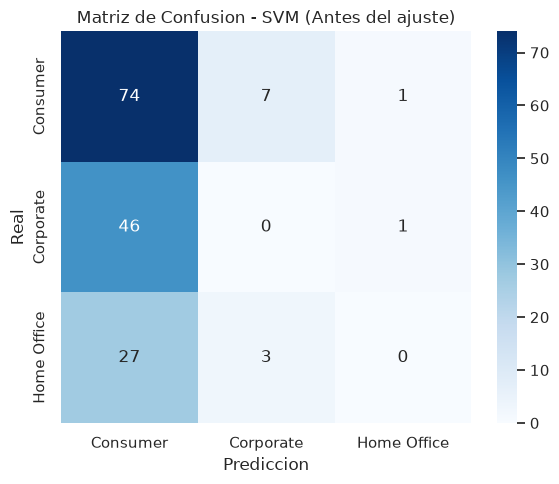

In [37]:
MODELOS_BASE[ModeloSVM.NOMBRE] = entrenar_modelo(ModeloSVM)
RESULTADOS_BASE[ModeloSVM.NOMBRE] = evaluar_modelo(ModeloSVM.NOMBRE, MODELOS_BASE[ModeloSVM.NOMBRE])

## 3.3 Modelo 2 — Regresión Logística

Modelo lineal que estima la probabilidad de cada clase (multinomial) con regularización L2 (`C=1`). Es el modelo más simple y el más difícil de sobreajustar; sirve como referencia de complejidad baja. `max_iter=1000` porque el valor por defecto no converge con tantas columnas *one-hot*.

**Entrenamiento, predicciones, métricas, matriz de confusión**

===== Regresion Logistica | Antes del ajuste =====

Metricas en el conjunto de PRUEBA (promedio macro):


,Valor
Accuracy,0.4843
Tasa de error,0.5157
Sensibilidad,0.3705
Especificidad,0.6905
Precision,0.3839
F1-Score,0.3584


Metricas por clase (uno-contra-el-resto):


,TP,FN,FP,TN,Sensibilidad,Especificidad,Precision,F1-Score
Clase,,,,,,,,
Consumer,62,20,51,26,0.7561,0.3377,0.5487,0.6359
Corporate,12,35,22,90,0.2553,0.8036,0.3529,0.2963
Home Office,3,27,9,120,0.1000,0.9302,0.2500,0.1429


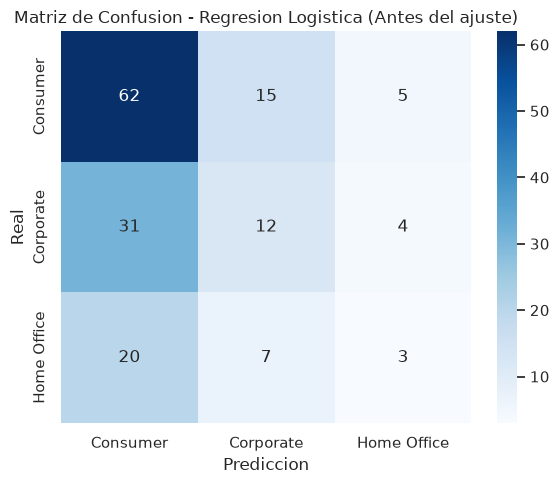

In [38]:
MODELOS_BASE[ModeloRegresionLogistica.NOMBRE] = entrenar_modelo(ModeloRegresionLogistica)
RESULTADOS_BASE[ModeloRegresionLogistica.NOMBRE] = evaluar_modelo(
    ModeloRegresionLogistica.NOMBRE, MODELOS_BASE[ModeloRegresionLogistica.NOMBRE])

## 3.4 Modelo 3 — Árbol de Decisión

Divide los datos con reglas sucesivas sobre las features. En su configuración base **no tiene poda** (`max_depth=None`), así que crece hasta clasificar perfectamente el entrenamiento.

**Entrenamiento, predicciones, métricas, matriz de confusión**

===== Arbol de Decision | Antes del ajuste =====

Metricas en el conjunto de PRUEBA (promedio macro):


,Valor
Accuracy,0.4403
Tasa de error,0.5597
Sensibilidad,0.3581
Especificidad,0.6745
Precision,0.3717
F1-Score,0.3558


Metricas por clase (uno-contra-el-resto):


,TP,FN,FP,TN,Sensibilidad,Especificidad,Precision,F1-Score
Clase,,,,,,,,
Consumer,51,31,48,29,0.6220,0.3766,0.5152,0.5635
Corporate,15,32,30,82,0.3191,0.7321,0.3333,0.3261
Home Office,4,26,11,118,0.1333,0.9147,0.2667,0.1778


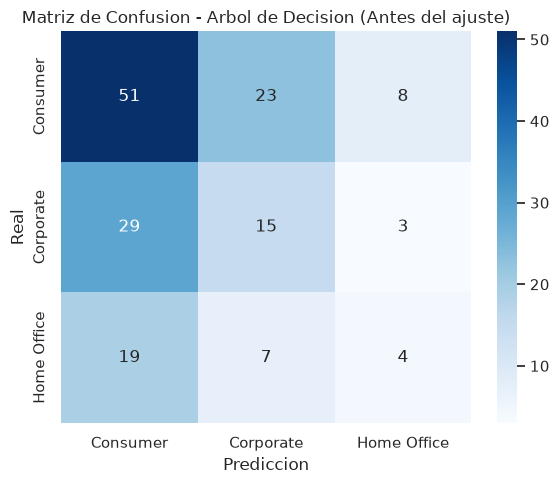

In [39]:
MODELOS_BASE[ModeloArbolDecision.NOMBRE] = entrenar_modelo(ModeloArbolDecision)
RESULTADOS_BASE[ModeloArbolDecision.NOMBRE] = evaluar_modelo(
    ModeloArbolDecision.NOMBRE, MODELOS_BASE[ModeloArbolDecision.NOMBRE])

## 3.5 Modelo 4 — Red Neuronal (MLP)

Perceptrón multicapa (`MLPClassifier`) con dos capas ocultas de 100 y 50 neuronas, activación ReLU, optimizador Adam y regularización L2 mínima (`alpha=1e-4`). Con ~600 registros y cientos de entradas.

**Entrenamiento, predicciones, métricas, matriz de confusión**

===== Red Neuronal MLP | Antes del ajuste =====

Metricas en el conjunto de PRUEBA (promedio macro):


,Valor
Accuracy,0.4528
Tasa de error,0.5472
Sensibilidad,0.3733
Especificidad,0.6882
Precision,0.3783
F1-Score,0.3725


Metricas por clase (uno-contra-el-resto):


,TP,FN,FP,TN,Sensibilidad,Especificidad,Precision,F1-Score
Clase,,,,,,,,
Consumer,52,30,44,33,0.6341,0.4286,0.5417,0.5843
Corporate,15,32,26,86,0.3191,0.7679,0.3659,0.3409
Home Office,5,25,17,112,0.1667,0.8682,0.2273,0.1923


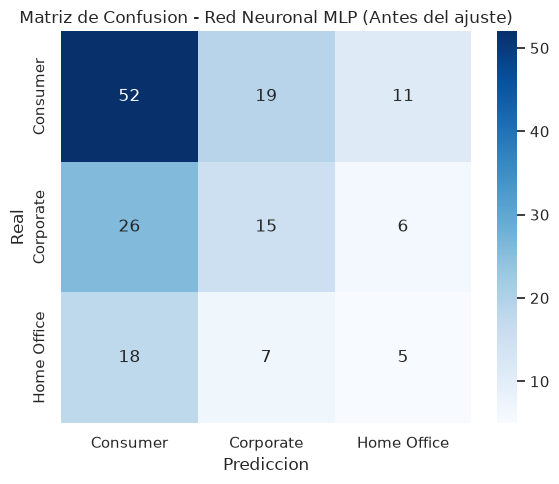

In [40]:
MODELOS_BASE[ModeloRedNeuronalMLP.NOMBRE] = entrenar_modelo(ModeloRedNeuronalMLP)
RESULTADOS_BASE[ModeloRedNeuronalMLP.NOMBRE] = evaluar_modelo(
    ModeloRedNeuronalMLP.NOMBRE, MODELOS_BASE[ModeloRedNeuronalMLP.NOMBRE])

## 3.6 Comparación de los modelos (configuración base)


In [41]:
def tabla_comparacion(resultados):
    filas = [{"Modelo": nombre, **r["metricas"]} for nombre, r in resultados.items()]
    return pd.DataFrame(filas)


def tabla_generalizacion(resultados):
    filas = []
    for nombre, r in resultados.items():
        filas.append({
            "Modelo": nombre,
            "Accuracy train": r["metricas_train"]["Accuracy"],
            "Accuracy test": r["metricas"]["Accuracy"],
            "Brecha (train - test)": r["metricas_train"]["Accuracy"] - r["metricas"]["Accuracy"],
        })
    return pd.DataFrame(filas)


tabla_base = tabla_comparacion(RESULTADOS_BASE)
print("Comparacion de los 4 modelos (test, promedio macro):")
display(tabla_base.round(4))
print(f"Linea base (predecir siempre '{CLASE_MAYORITARIA}'): Accuracy = {ACC_LINEA_BASE:.4f}\n")
print("Diagnostico de generalizacion:")
display(tabla_generalizacion(RESULTADOS_BASE).round(4))

Comparacion de los 4 modelos (test, promedio macro):


,Modelo,Accuracy,Tasa de error,Sensibilidad,Especificidad,Precision,F1-Score
0,SVM,0.4654,0.5346,0.3008,0.6491,0.1678,0.2154
1,Regresion Logistica,0.4843,0.5157,0.3705,0.6905,0.3839,0.3584
2,Arbol de Decision,0.4403,0.5597,0.3581,0.6745,0.3717,0.3558
3,Red Neuronal MLP,0.4528,0.5472,0.3733,0.6882,0.3783,0.3725


Linea base (predecir siempre 'Consumer'): Accuracy = 0.5157

Diagnostico de generalizacion:


,Modelo,Accuracy train,Accuracy test,Brecha (train - test)
0,SVM,0.6293,0.4654,0.1639
1,Regresion Logistica,0.7129,0.4843,0.2287
2,Arbol de Decision,0.9858,0.4403,0.5456
3,Red Neuronal MLP,0.8975,0.4528,0.4446


In [42]:
mejor_f1 = tabla_base.loc[tabla_base["F1-Score"].idxmax(), "Modelo"]
mayor_brecha = tabla_generalizacion(RESULTADOS_BASE).sort_values("Brecha (train - test)").iloc[-1]
print(f"- Mayor F1-Score macro en test: {mejor_f1}.")
print(f"- Mayor brecha train-test: {mayor_brecha['Modelo']} ({mayor_brecha['Brecha (train - test)']:+.1%}).")
print(f"- Una exactitud cercana a la linea base ({ACC_LINEA_BASE:.1%}) indica que la ubicacion y la edad "
      "aportan poca informacion sobre el segmento; la ventaja de un modelo debe leerse junto con "
      "sensibilidad/F1 macro y la brecha train-test, no solo con la exactitud.")

- Mayor F1-Score macro en test: Red Neuronal MLP.
- Mayor brecha train-test: Arbol de Decision (+54.6%).
- Una exactitud cercana a la linea base (51.6%) indica que la ubicacion y la edad aportan poca informacion sobre el segmento; la ventaja de un modelo debe leerse junto con sensibilidad/F1 macro y la brecha train-test, no solo con la exactitud.


Lectura de la comparación: con este dataset las diferencias entre modelos suelen ser pequeñas y la exactitud queda cerca de la línea base; por eso conviene mirar la **sensibilidad y el F1 macro** (¿el modelo detecta también las clases minoritarias?) y la **brecha entre entrenamiento y prueba** (¿generaliza o memoriza?). Esas dos ideas guían el ajuste de la sección siguiente.

## 3.7 Ajuste de los modelos y prevención de overfitting

**Objetivo.** No buscar la métrica más alta, sino un modelo que **generalice**: que rinda bien con datos nuevos y no solo con los de entrenamiento (*overfitting* = memorizar).

**Método.**
1. Se usa **solo `X_train`**; el conjunto de prueba no interviene en la elección.
2. **Validación cruzada de 5 folds**: los datos de entrenamiento se dividen en 5 partes y cada configuración se entrena con 4 y se valida con la restante. El preprocesador va dentro del `Pipeline`, así que se reaprende en cada fold (sin *leakage*).
3. **`GridSearchCV`** prueba todas las combinaciones de las grillas de abajo.
4. **Rendimiento** = promedio de `f1_macro` y `balanced_accuracy`. La `accuracy` solo se reporta, porque en un problema desbalanceado premia predecir siempre `Consumer`.
5. **Control de overfitting:** se descartan las configuraciones que rinden más de **0,10** mejor en entrenamiento que en validación (señal de memorización) y, entre las restantes, se elige la de mejor rendimiento en validación. Si ninguna cumple, la de menor diferencia.

**Hiperparámetros ajustados.**

| Modelo | Hiperparámetros | Para qué |
|---|---|---|
| SVM | `C`, `kernel`, `gamma`, `class_weight` | Controlan qué tan compleja es la frontera; `class_weight="balanced"` da más peso a las clases con menos clientes. |
| Regresión Logística | `C`, `class_weight` | `C` menor = modelo más simple (más regularización). |
| Árbol de Decisión | `max_depth`, `min_samples_split`, `min_samples_leaf`, `class_weight` | Limitan la profundidad y el tamaño de las hojas para que no memorice. |
| Red Neuronal | `hidden_layer_sizes`, `activation`, `alpha`, `early_stopping` | Tamaño de la red, tipo de activación, regularización y parada temprana. |

In [43]:
SCORING = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",   # = sensibilidad macro
}
METRICAS_SELECCION = ["f1_macro", "balanced_accuracy"]   # sin accuracy: premia predecir siempre la clase mayoritaria
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

ESPACIOS_BUSQUEDA = {
    ModeloSVM.NOMBRE: {
        "model__C": [0.1, 1, 10, 100],
        "model__kernel": ["rbf", "linear"],
        "model__gamma": ["scale", 0.001, 0.01],
        "model__class_weight": [None, "balanced"],
    },
    ModeloRegresionLogistica.NOMBRE: {
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"],
    },
    ModeloArbolDecision.NOMBRE: {
        "model__max_depth": [2, 3, 4, 5, 7, 10, None],
        "model__min_samples_split": [2, 10, 20, 40],
        "model__min_samples_leaf": [1, 5, 10, 20],
        "model__class_weight": [None, "balanced"],
    },
    ModeloRedNeuronalMLP.NOMBRE: {
        "model__hidden_layer_sizes": [(32,), (64,), (100, 50)],
        "model__activation": ["relu", "tanh"],
        "model__alpha": [1e-4, 1e-2, 1, 10],
        "model__early_stopping": [False, True],
    },
}


def rendimiento_cv(resultados_cv, prefijo):
    return np.mean([np.asarray(resultados_cv[f"{prefijo}_{m}"]) for m in METRICAS_SELECCION], axis=0)


def elegir_por_generalizacion(val, gap, gap_max=GAP_MAX_CV):
    val, gap = np.asarray(val), np.asarray(gap)
    validos = np.flatnonzero(gap <= gap_max)
    if validos.size == 0:
        return int(np.argmin(gap))
    return int(max(validos, key=lambda i: (round(val[i], 4), -gap[i])))


def refit_menor_overfitting(resultados_cv):
    val = rendimiento_cv(resultados_cv, "mean_test")
    gap = rendimiento_cv(resultados_cv, "mean_train") - val
    return elegir_por_generalizacion(val, gap)


def ajustar_modelo(modulo):
    busqueda = GridSearchCV(
        estimator=crear_pipeline(modulo),
        param_grid=ESPACIOS_BUSQUEDA[modulo.NOMBRE],
        scoring=SCORING,
        refit=refit_menor_overfitting,
        cv=CV,
        n_jobs=N_JOBS,
        return_train_score=True,
    )
    busqueda.fit(X_train, y_train)
    return busqueda


BUSQUEDAS = {}
for modulo in MODULOS:
    n_comb = int(np.prod([len(v) for v in ESPACIOS_BUSQUEDA[modulo.NOMBRE].values()]))
    print(f"Ajustando {modulo.NOMBRE}: {n_comb} combinaciones x {CV_FOLDS} folds ...")
    BUSQUEDAS[modulo.NOMBRE] = ajustar_modelo(modulo)
print("Busqueda terminada.")

Ajustando SVM: 48 combinaciones x 5 folds ...
Ajustando Regresion Logistica: 10 combinaciones x 5 folds ...
Ajustando Arbol de Decision: 224 combinaciones x 5 folds ...
Ajustando Red Neuronal MLP: 48 combinaciones x 5 folds ...
Busqueda terminada.


### 3.7.1 Mejores hiperparámetros encontrados

In [44]:
filas = []
for nombre, b in BUSQUEDAS.items():
    for param, valor in b.best_params_.items():
        filas.append({"Modelo": nombre, "Hiperparametro": param.replace("model__", ""), "Mejor valor": valor})
display(pd.DataFrame(filas).set_index(["Modelo", "Hiperparametro"]))

Mejor valor
Modelo              Hiperparametro                
SVM                 C                           10
                    class_weight          balanced
                    gamma                    0.001
                    kernel                     rbf
Regresion Logistica C                        0.001
                    class_weight          balanced
Arbol de Decision   class_weight          balanced
                    max_depth                    7
                    min_samples_leaf            20
                    min_samples_split            2
Red Neuronal MLP    activation                relu
                    alpha                       10
                    early_stopping            True
                    hidden_layer_sizes       (32,)

### 3.7.2 Rendimiento en validación cruzada: antes vs. después del ajuste

Para comparar de forma justa se evalúa también la **configuración base** de cada modelo con **la misma validación cruzada** (sobre `X_train`).El rendimiento es la media de F1 macro y balanced accuracy, la *brecha* es train − validación.

In [45]:
def cv_configuracion_base(modulo):
    r = cross_validate(crear_pipeline(modulo), X_train, y_train, scoring=SCORING,
                       cv=CV, n_jobs=N_JOBS, return_train_score=True)
    train = np.mean([r[f"train_{m}"].mean() for m in METRICAS_SELECCION])
    val = np.mean([r[f"test_{m}"].mean() for m in METRICAS_SELECCION])
    return train, val


filas_cv, CV_RESUMEN = [], {}
for modulo in MODULOS:
    tr0, va0 = cv_configuracion_base(modulo)
    b = BUSQUEDAS[modulo.NOMBRE]
    i = b.best_index_
    tr1 = float(rendimiento_cv(b.cv_results_, "mean_train")[i])
    va1 = float(rendimiento_cv(b.cv_results_, "mean_test")[i])
    CV_RESUMEN[modulo.NOMBRE] = {"train": tr1, "val": va1, "gap": tr1 - va1}
    filas_cv.append({"Modelo": modulo.NOMBRE, "Etapa": "Antes (base)", "CV train": tr0, "CV validacion": va0, "Brecha": tr0 - va0})
    filas_cv.append({"Modelo": modulo.NOMBRE, "Etapa": "Despues (ajustado)", "CV train": tr1, "CV validacion": va1, "Brecha": tr1 - va1})

tabla_cv = pd.DataFrame(filas_cv)
display(tabla_cv.round(4))

,Modelo,Etapa,CV train,CV validacion,Brecha
0,SVM,Antes (base),0.5105,0.2913,0.2192
1,SVM,Despues (ajustado),0.3844,0.3147,0.0697
2,Regresion Logistica,Antes (base),0.6610,0.3174,0.3436
3,Regresion Logistica,Despues (ajustado),0.4269,0.3328,0.0942
4,Arbol de Decision,Antes (base),0.9843,0.3601,0.6242
5,Arbol de Decision,Despues (ajustado),0.4574,0.3650,0.0924
6,Red Neuronal MLP,Antes (base),0.9525,0.3512,0.6013
7,Red Neuronal MLP,Despues (ajustado),0.3160,0.3066,0.0094


### 3.7.3 Evaluación de los modelos ajustados (conjunto de prueba)

Los modelos ajustados (`best_estimator_`, reentrenados con todo `X_train` y los mejores hiperparámetros) se evalúan **una sola vez** sobre el conjunto de prueba, con las mismas métricas, matriz de confusión e interpretación.

#### SVM ajustada

===== SVM | Despues del ajuste =====

Metricas en el conjunto de PRUEBA (promedio macro):


,Valor
Accuracy,0.2642
Tasa de error,0.7358
Sensibilidad,0.3068
Especificidad,0.6611
Precision,0.3332
F1-Score,0.2505


Metricas por clase (uno-contra-el-resto):


,TP,FN,FP,TN,Sensibilidad,Especificidad,Precision,F1-Score
Clase,,,,,,,,
Consumer,9,73,7,70,0.1098,0.9091,0.5625,0.1837
Corporate,24,23,62,50,0.5106,0.4464,0.2791,0.3609
Home Office,9,21,48,81,0.3000,0.6279,0.1579,0.2069


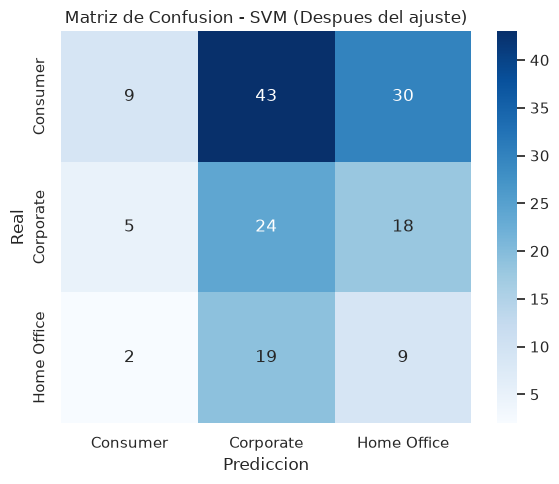

In [46]:
MODELOS_AJUSTADOS, RESULTADOS_AJUSTADOS = {}, {}
MODELOS_AJUSTADOS[ModeloSVM.NOMBRE] = BUSQUEDAS[ModeloSVM.NOMBRE].best_estimator_
RESULTADOS_AJUSTADOS[ModeloSVM.NOMBRE] = evaluar_modelo(
    ModeloSVM.NOMBRE, MODELOS_AJUSTADOS[ModeloSVM.NOMBRE], "Despues del ajuste")

#### Regresión Logística ajustada

===== Regresion Logistica | Despues del ajuste =====

Metricas en el conjunto de PRUEBA (promedio macro):


,Valor
Accuracy,0.2579
Tasa de error,0.7421
Sensibilidad,0.2946
Especificidad,0.6524
Precision,0.3026
F1-Score,0.2540


Metricas por clase (uno-contra-el-resto):


,TP,FN,FP,TN,Sensibilidad,Especificidad,Precision,F1-Score
Clase,,,,,,,,
Consumer,12,70,13,64,0.1463,0.8312,0.4800,0.2243
Corporate,19,28,51,61,0.4043,0.5446,0.2714,0.3248
Home Office,10,20,54,75,0.3333,0.5814,0.1562,0.2128


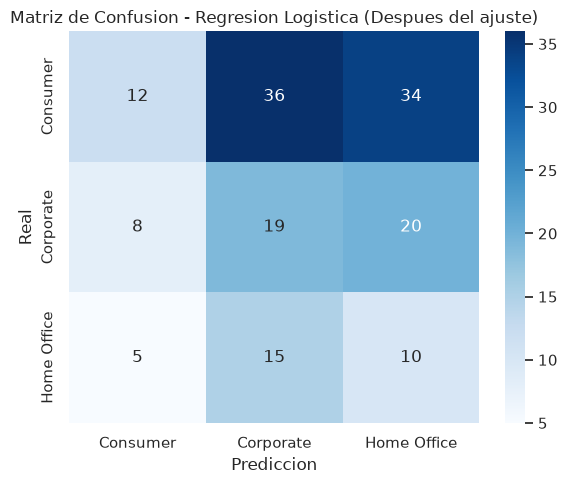

In [47]:
MODELOS_AJUSTADOS[ModeloRegresionLogistica.NOMBRE] = BUSQUEDAS[ModeloRegresionLogistica.NOMBRE].best_estimator_
RESULTADOS_AJUSTADOS[ModeloRegresionLogistica.NOMBRE] = evaluar_modelo(
    ModeloRegresionLogistica.NOMBRE, MODELOS_AJUSTADOS[ModeloRegresionLogistica.NOMBRE], "Despues del ajuste")

#### Árbol de Decisión ajustado

===== Arbol de Decision | Despues del ajuste =====

Metricas en el conjunto de PRUEBA (promedio macro):


,Valor
Accuracy,0.2893
Tasa de error,0.7107
Sensibilidad,0.3562
Especificidad,0.6685
Precision,0.3313
F1-Score,0.2895


Metricas por clase (uno-contra-el-resto):


,TP,FN,FP,TN,Sensibilidad,Especificidad,Precision,F1-Score
Clase,,,,,,,,
Consumer,14,68,15,62,0.1707,0.8052,0.4828,0.2523
Corporate,14,33,34,78,0.2979,0.6964,0.2917,0.2947
Home Office,18,12,64,65,0.6000,0.5039,0.2195,0.3214


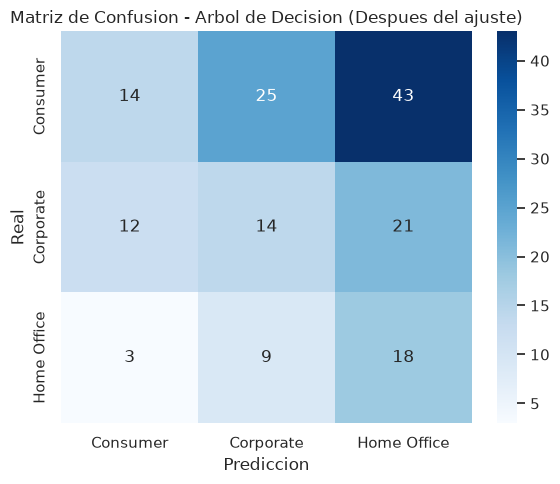

In [48]:
MODELOS_AJUSTADOS[ModeloArbolDecision.NOMBRE] = BUSQUEDAS[ModeloArbolDecision.NOMBRE].best_estimator_
RESULTADOS_AJUSTADOS[ModeloArbolDecision.NOMBRE] = evaluar_modelo(
    ModeloArbolDecision.NOMBRE, MODELOS_AJUSTADOS[ModeloArbolDecision.NOMBRE], "Despues del ajuste")

#### Red Neuronal ajustada

===== Red Neuronal MLP | Despues del ajuste =====

Metricas en el conjunto de PRUEBA (promedio macro):


,Valor
Accuracy,0.4969
Tasa de error,0.5031
Sensibilidad,0.3272
Especificidad,0.6645
Precision,0.2389
F1-Score,0.2456


Metricas por clase (uno-contra-el-resto):


,TP,FN,FP,TN,Sensibilidad,Especificidad,Precision,F1-Score
Clase,,,,,,,,
Consumer,77,5,72,5,0.9390,0.0649,0.5168,0.6667
Corporate,2,45,8,104,0.0426,0.9286,0.2000,0.0702
Home Office,0,30,0,129,0.0000,1.0000,0.0000,0.0000


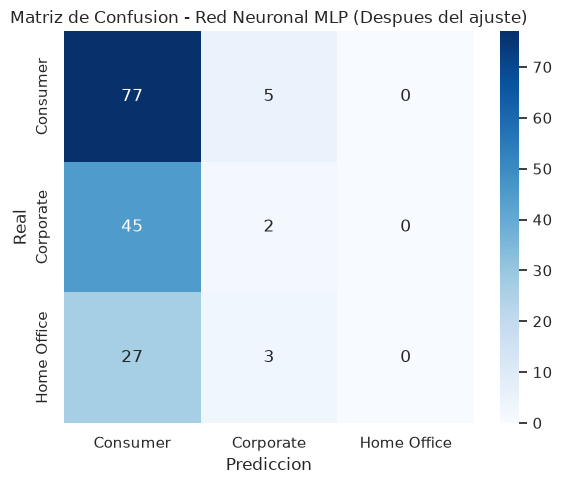

In [49]:
MODELOS_AJUSTADOS[ModeloRedNeuronalMLP.NOMBRE] = BUSQUEDAS[ModeloRedNeuronalMLP.NOMBRE].best_estimator_
RESULTADOS_AJUSTADOS[ModeloRedNeuronalMLP.NOMBRE] = evaluar_modelo(
    ModeloRedNeuronalMLP.NOMBRE, MODELOS_AJUSTADOS[ModeloRedNeuronalMLP.NOMBRE], "Despues del ajuste")

### 3.7.4 Comparación antes vs. después del ajuste (conjunto de prueba)

In [50]:
nombres_modelos = [m.NOMBRE for m in MODULOS]
filas_ad = []
for n in nombres_modelos:
    filas_ad.append({"Modelo": n, "Etapa": "Antes (base)", **RESULTADOS_BASE[n]["metricas"]})
    filas_ad.append({"Modelo": n, "Etapa": "Despues (ajustado)", **RESULTADOS_AJUSTADOS[n]["metricas"]})
tabla_antes_despues = pd.DataFrame(filas_ad).set_index(["Modelo", "Etapa"])
print("Metricas en test - Antes vs Despues del ajuste:")
display(tabla_antes_despues.round(4))

print("Generalizacion (Accuracy train vs test) - Despues del ajuste:")
display(tabla_generalizacion(RESULTADOS_AJUSTADOS).round(4))

Metricas en test - Antes vs Despues del ajuste:


Accuracy  Tasa de error  Sensibilidad  \
Modelo              Etapa                                                       
SVM                 Antes (base)          0.4654         0.5346        0.3008   
                    Despues (ajustado)    0.2642         0.7358        0.3068   
Regresion Logistica Antes (base)          0.4843         0.5157        0.3705   
                    Despues (ajustado)    0.2579         0.7421        0.2946   
Arbol de Decision   Antes (base)          0.4403         0.5597        0.3581   
                    Despues (ajustado)    0.2893         0.7107        0.3562   
Red Neuronal MLP    Antes (base)          0.4528         0.5472        0.3733   
                    Despues (ajustado)    0.4969         0.5031        0.3272   

                                        Especificidad  Precision  F1-Score  
Modelo              Etapa                                                   
SVM                 Antes (base)               0.6491     0.1678    0.2154  
                    Despues (ajustado)         0.6611     0.3332    0.2505  
Regresion Logistica Antes (base)               0.6905     0.3839    0.3584  
                    Despues (ajustado)         0.6524     0.3026    0.2540  
Arbol de Decision   Antes (base)               0.6745     0.3717    0.3558  
                    Despues (ajustado)         0.6685     0.3313    0.2895  
Red Neuronal MLP    Antes (base)               0.6882     0.3783    0.3725  
                    Despues (ajustado)         0.6645     0.2389    0.2456

Generalizacion (Accuracy train vs test) - Despues del ajuste:


,Modelo,Accuracy train,Accuracy test,Brecha (train - test)
0,SVM,0.3644,0.2642,0.1002
1,Regresion Logistica,0.3927,0.2579,0.1349
2,Arbol de Decision,0.3943,0.2893,0.1050
3,Red Neuronal MLP,0.5284,0.4969,0.0315


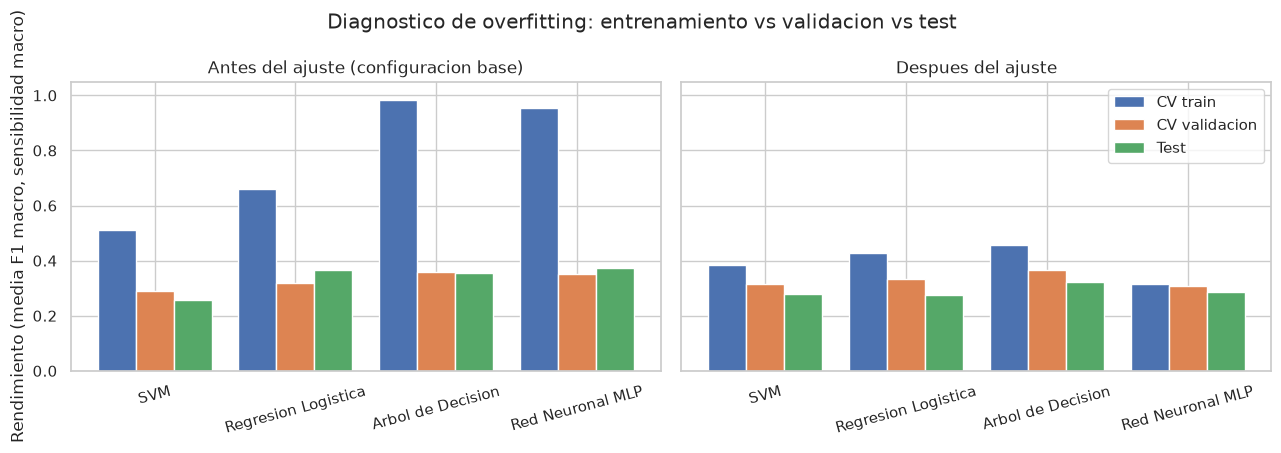

In [51]:
def rendimiento_test(res):
    m = res["metricas"]
    return np.mean([m["F1-Score"], m["Sensibilidad"]])

nombres = [m.NOMBRE for m in MODULOS]
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
x, ancho = np.arange(len(nombres)), 0.27

cv_base = tabla_cv[tabla_cv["Etapa"] == "Antes (base)"].set_index("Modelo")
ejes[0].bar(x - ancho, cv_base.loc[nombres, "CV train"], ancho, label="CV train")
ejes[0].bar(x, cv_base.loc[nombres, "CV validacion"], ancho, label="CV validacion")
ejes[0].bar(x + ancho, [rendimiento_test(RESULTADOS_BASE[n]) for n in nombres], ancho, label="Test")
ejes[0].set_title("Antes del ajuste (configuracion base)")

ejes[1].bar(x - ancho, [CV_RESUMEN[n]["train"] for n in nombres], ancho, label="CV train")
ejes[1].bar(x, [CV_RESUMEN[n]["val"] for n in nombres], ancho, label="CV validacion")
ejes[1].bar(x + ancho, [rendimiento_test(RESULTADOS_AJUSTADOS[n]) for n in nombres], ancho, label="Test")
ejes[1].set_title("Despues del ajuste")

for eje in ejes:
    eje.set_xticks(x)
    eje.set_xticklabels(nombres, rotation=15)
    eje.set_ylim(0, 1.05)
ejes[0].set_ylabel("Rendimiento (media F1 macro, sensibilidad macro)")
ejes[1].legend(loc="upper right")
plt.suptitle("Diagnostico de overfitting: entrenamiento vs validacion vs test")
plt.tight_layout()
plt.show()

### 3.7.5 Selección del modelo final

La elección **no se hace con el valor más alto de una sola métrica ni mirando el conjunto de prueba**. Se aplica el mismo criterio que en el ajuste, ahora *entre modelos* y usando únicamente los resultados de **validación cruzada sobre `X_train`**:

1. Se descartan los modelos cuya brecha de entrenamiento−validación supera `GAP_MAX_CV` (señal de sobreajuste).
2. Entre los restantes se elige el de mayor **rendimiento de validación** (media de F1 macro y sensibilidad macro).
3. El conjunto de prueba se usa solo como **confirmación**: el rendimiento en test debe ser coherente con el de validación (si no lo fuera, sería una señal de alarma).

In [52]:
tabla_seleccion = pd.DataFrame([
    {"Modelo": n,
     "CV train": CV_RESUMEN[n]["train"],
     "CV validacion": CV_RESUMEN[n]["val"],
     "Brecha CV": CV_RESUMEN[n]["gap"],
     "Cumple brecha": CV_RESUMEN[n]["gap"] <= GAP_MAX_CV,
     "Rendimiento test (confirmacion)": rendimiento_test(RESULTADOS_AJUSTADOS[n]),
     "|Test - CV validacion|": abs(rendimiento_test(RESULTADOS_AJUSTADOS[n]) - CV_RESUMEN[n]["val"])}
    for n in nombres
]).set_index("Modelo")
display(tabla_seleccion.round(4))

idx = elegir_por_generalizacion(tabla_seleccion["CV validacion"], tabla_seleccion["Brecha CV"])
NOMBRE_MODELO_FINAL = tabla_seleccion.index[idx]
modelo_final = MODELOS_AJUSTADOS[NOMBRE_MODELO_FINAL]
fila = tabla_seleccion.loc[NOMBRE_MODELO_FINAL]
met_final = RESULTADOS_AJUSTADOS[NOMBRE_MODELO_FINAL]["metricas"]

print(f"MODELO FINAL SELECCIONADO: {NOMBRE_MODELO_FINAL}")
print(f"  Hiperparametros: { {k.replace('model__', ''): v for k, v in BUSQUEDAS[NOMBRE_MODELO_FINAL].best_params_.items()} }")
print(f"  Rendimiento CV: train = {fila['CV train']:.3f} | validacion = {fila['CV validacion']:.3f} | brecha = {fila['Brecha CV']:.3f} (limite {GAP_MAX_CV})")
print(f"  Test (confirmacion): Accuracy = {met_final['Accuracy']:.3f} | Sensibilidad = {met_final['Sensibilidad']:.3f} | F1 = {met_final['F1-Score']:.3f}")
print(f"  Linea base (clase mayoritaria): Accuracy = {ACC_LINEA_BASE:.3f}")
mas_alto = tabla_seleccion["Rendimiento test (confirmacion)"].idxmax()
if mas_alto != NOMBRE_MODELO_FINAL:
    print(f"  Nota: '{mas_alto}' tiene el mayor rendimiento en test, pero no se elige por ese valor: "
          "la decision se basa en validacion cruzada y control de la brecha, no en test.")

,CV train,CV validacion,Brecha CV,Cumple brecha,Rendimiento test (confirmacion),|Test - CV validacion|
Modelo,,,,,,
SVM,0.3844,0.3147,0.0697,True,0.2786,0.0361
Regresion Logistica,0.4269,0.3328,0.0942,True,0.2743,0.0585
Arbol de Decision,0.4574,0.3650,0.0924,True,0.3228,0.0421
Red Neuronal MLP,0.3160,0.3066,0.0094,True,0.2864,0.0202


MODELO FINAL SELECCIONADO: Arbol de Decision
  Hiperparametros: {'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 2}
  Rendimiento CV: train = 0.457 | validacion = 0.365 | brecha = 0.092 (limite 0.1)
  Test (confirmacion): Accuracy = 0.289 | Sensibilidad = 0.356 | F1 = 0.289
  Linea base (clase mayoritaria): Accuracy = 0.516


**Justificación de la elección.** El modelo final es el que ofrece el mejor equilibrio entre rendimiento y capacidad de generalización *según la validación cruzada*: una brecha train–validación dentro del límite establecido y el mayor rendimiento entre los que la cumplen. Se destacan tres ideas:
- **El ajuste reduce el sobreajuste**: las brechas train–validación en CV bajan de 0.22–0.62 a menos de 0.10 (el MLP llega a 0 porque colapsa a predecir siempre `Consumer`). En test la exactitud baja, porque `class_weight="balanced"` y la regularización hacen que el modelo deje de favorecer a la clase mayoritaria, y el F1 macro solo mejora en el SVM.
- **La exactitud absoluta es modesta** porque las variables disponibles (edad y ubicación) contienen poca información sobre el segmento. Esto ya se anticipó en 2.1: los resultados deben leerse como una orientación, no como una predicción fiable, y se compararon contra la línea base.
- **Reglas de decisión honestas**: el conjunto de prueba nunca intervino en la elección de hiperparámetros ni del modelo; su papel fue solo confirmar que el rendimiento esperado (validación) se mantiene en datos no vistos.

# 4. Predicciones con datos ingresados por el usuario

En esta sección el usuario introduce las características de un cliente nuevo y el **modelo final** (seleccionado en 3.7.5) predice su segmento.

**Flujo:**
1. Se solicitan los datos (`age`, `city`, `state`, `postal_code`, `region`).
2. Se validan y convierten (edad numérica y en rango, código postal numérico, categorías comparadas con las conocidas sin distinguir mayúsculas).
3. Los datos se arman como un `DataFrame` con **las mismas columnas y tipos** que `X_train` (en especial `postal_code` como texto sin ceros a la izquierda, igual que en la limpieza).
4. Se pasan por `modelo_final`, que es un `Pipeline`: aplica **exactamente el mismo preprocesamiento aprendido con el entrenamiento** (imputación, escalado de la edad y *one-hot*) y luego el clasificador. No se reajusta nada con los datos del usuario.
5. Se muestra la clase predicha y se explica su significado.

In [53]:
DESCRIPCION_SEGMENTOS = {
    "Consumer": "cliente individual que compra para uso personal o del hogar (consumidor final).",
    "Corporate": "cliente empresarial: compra en nombre de una organizacion o corporacion.",
    "Home Office": "cliente que compra para una pequena oficina o trabajo desde casa (profesional independiente / micro-empresa).",
}
CATEGORIAS_CONOCIDAS = {c: sorted(X_train[c].unique()) for c in FEATURES_CAT}
MAPA_ESTADO_REGION = X_train.groupby("state")["region"].agg(lambda s: s.mode().iloc[0]).to_dict()
EDAD_MIN, EDAD_MAX = int(X_train["age"].min()), int(X_train["age"].max())


def _canonizar(valor, conocidas):
    """Devuelve la categoria conocida que coincide sin distinguir mayusculas, o None."""
    return {c.lower(): c for c in conocidas}.get(valor.strip().lower())


def construir_registro(datos):
    """DataFrame de 1 fila con las mismas columnas/tipos que X_train (entrada del Pipeline)."""
    return pd.DataFrame([{
        "age": float(datos["age"]),
        "city": datos["city"],
        "state": datos["state"],
        "postal_code": str(datos["postal_code"]),
        "region": datos["region"],
    }])[FEATURES_NUM + FEATURES_CAT]


def predecir_segmento(modelo, datos):
    """Aplica el Pipeline completo (preprocesamiento del entrenamiento + clasificador)."""
    registro = construir_registro(datos)
    clase = modelo.predict(registro)[0]
    probabilidades = None
    if hasattr(modelo, "predict_proba"):
        probabilidades = dict(zip(modelo.classes_, modelo.predict_proba(registro)[0]))
    return clase, probabilidades


def mostrar_resultado(nombre_modelo, datos, clase, probabilidades):
    print("\n================ RESULTADO ================")
    print(f"Modelo utilizado : {nombre_modelo}")
    print(f"Datos ingresados : {datos}")
    print(f"\n-> Segmento predicho: {clase.upper()}")
    if probabilidades:
        print("   Probabilidad estimada por segmento:")
        for c, p in sorted(probabilidades.items(), key=lambda kv: -kv[1]):
            print(f"     {c:<12s} {p:6.1%}")


def solicitar_datos_usuario():
    print(f"=== PREDICCION INTERACTIVA (Modelo final: {NOMBRE_MODELO_FINAL}) ===")
    return {
        "age": int(input("1. Edad del cliente (ej. 35): ")),
        "city": input("2. Ciudad (ej. Los Angeles): ").strip(),
        "state": input("3. Estado (ej. California): ").strip(),
        "postal_code": input("4. Codigo postal (ej. 90036): ").strip(),
        "region": input(f"5. Region {CATEGORIAS_CONOCIDAS['region']}: ").strip(),
    }

### Ingreso de datos y predicción

Al ejecutar la celda siguiente se piden los cinco datos por teclado. Con `MODO_INTERACTIVO = False` (sección 0) se omite el ingreso y se usa un cliente de ejemplo del conjunto de prueba.

In [54]:
if MODO_INTERACTIVO:
    datos_usuario = solicitar_datos_usuario()
else:
    datos_usuario = X_test.iloc[0].to_dict()
    print("MODO_INTERACTIVO = False -> se usa un cliente de ejemplo del conjunto de prueba.")

clase_predicha, probabilidades = predecir_segmento(modelo_final, datos_usuario)
mostrar_resultado(NOMBRE_MODELO_FINAL, datos_usuario, clase_predicha, probabilidades)

=== PREDICCION INTERACTIVA (Modelo final: Arbol de Decision) ===

================ RESULTADO ================
Modelo utilizado : Arbol de Decision
Datos ingresados : {'age': 33, 'city': 'Los Angeles', 'state': 'California', 'postal_code': '90035', 'region': 'West'}

-> Segmento predicho: CONSUMER
   Probabilidad estimada por segmento:
     Consumer      44.7%
     Home Office   44.2%
     Corporate     11.0%
